# Inspect swing-shape clustering

- `swings` - competitive-swing model table (`data/swings_model.parquet`)
- `assign` - per-swing cluster assignment (`play_id, batter_id, cluster, resp_max`)
- `summary` - per-(batter, cluster) raw-unit centroids + usage weight
- `rep` - per-batter repertoire (`k, bic, effective_shapes`, ...)
- `swc` - `swings` left-joined with `assign` (per-swing frame with features + context + value + cluster)

Helpers: `SHAPE` (5 clustering features), `RAW_SHAPE` (unmirrored), `by_name(s)` to find a batter_id.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
print('data dir:', DATA)

SHAPE = ['swing_path_tilt', 'swing_length', 'bat_speed', 'vert_attack_angle', 'horz_attack_angle_pull']
RAW_SHAPE = ['swing_path_tilt', 'swing_length', 'bat_speed', 'vert_attack_angle', 'horz_attack_angle']

# where rendered plots are written for the repo (results/plots/)
PLOTS = ROOT / 'results' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
print('plots dir:', PLOTS)


data dir: c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\data
plots dir: c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots


In [51]:
swings  = pd.read_parquet(DATA / 'swings_model.parquet')
assign  = pd.read_parquet(DATA / 'cluster_assignments.parquet')
summary = pd.read_parquet(DATA / 'cluster_summary.parquet')
rep     = pd.read_parquet(DATA / 'batter_repertoire.parquet')

for name, d in [('swings', swings), ('assign', assign), ('summary', summary), ('rep', rep)]:
    print(f'{name:8s} {d.shape}')

swings   (795723, 40)
assign   (780328, 5)
summary  (1592, 12)
rep      (703, 11)


In [52]:
# per-swing analysis frame: features + context + value + assigned cluster (cohort swings only)
swc = swings.merge(assign[['play_id', 'cluster', 'resp_max']], on='play_id', how='inner')
print('swc', swc.shape)

def by_name(s):
    """Return rep rows whose batter_full_name contains s (case-insensitive)."""
    return rep[rep.batter_full_name.str.contains(s, case=False, na=False)]

swc (780328, 42)


In [53]:
# quick peek
display(rep.head())
display(summary.head())
display(swc.head())

,batter_id,batter_stand,batter_full_name,label,n_swings,k,bic,min_weight,min_comp_n,usage_entropy,effective_shapes
0,444482,L,David Peralta,David Peralta,500,2,5366.4,0.4940,247,0.693,2.00
1,453568,L,Charlie Blackmon,Charlie Blackmon,817,3,8797.7,0.1151,94,0.963,2.62
2,455117,R,Martín Maldonado,Martín Maldonado,449,2,4969.0,0.4878,219,0.693,2.00
3,456781,R,Donovan Solano,Donovan Solano,888,2,9747.7,0.4989,443,0.693,2.00
4,457705,R,Andrew McCutchen,Andrew McCutchen,1906,2,21290.5,0.2508,478,0.563,1.76


,batter_id,batter_stand,batter_full_name,label,cluster,n,weight,swing_path_tilt_mean,swing_length_mean,bat_speed_mean,vert_attack_angle_mean,horz_attack_angle_mean
0,444482,L,David Peralta,David Peralta,0,253,0.5060,29.111,6.521,69.200,-0.704,12.771
1,444482,L,David Peralta,David Peralta,1,247,0.4940,32.766,7.761,72.265,11.703,-14.840
2,453568,L,Charlie Blackmon,Charlie Blackmon,0,409,0.5006,34.937,7.518,67.082,11.517,-10.008
3,453568,L,Charlie Blackmon,Charlie Blackmon,1,314,0.3843,26.807,6.787,67.938,7.602,-0.437
4,453568,L,Charlie Blackmon,Charlie Blackmon,2,94,0.1151,28.905,6.200,60.641,0.868,6.186


,play_id,game_pk,game_date,game_year,batter_id,batter_full_name,batter_stand,pitcher_id,pitcher_throws,balls,strikes,outs_when_up,plate_x,plate_z,plate_zone,pitch_type,on_1b_id,on_2b_id,on_3b_id,delta_run_exp,woba,xwoba,exit_velo,launch_angle,bearing_angle,pitch_outcome,pa_outcome,is_whiff,is_contact,is_bip,ball_bat_intercept_y,sz_top,sz_bot,height,swing_path_tilt,swing_length,bat_speed,vert_attack_angle,horz_attack_angle,horz_attack_angle_pull,cluster,resp_max
0,001848c7-9251-4b7e-8311-8679799076c1,745408,2024-06-06,2024,444482,David Peralta,L,677944,R,0,0,2,-0.093388,2.12002,8.0,FF,630105.0,665487.0,NaN,-0.048,NaN,NaN,66.6,48.0,NaN,S,NaN,0,1,0,1.389080,3.51,1.69,73,38.5906,7.4,69.4,3.67121,-9.17984,9.17984,1,0.729
1,0168c81f-8927-4514-8f83-38b5514293fd,746515,2024-08-17,2024,444482,David Peralta,L,664875,R,0,1,2,-0.415410,2.41925,4.0,ST,673490.0,NaN,592518.0,-0.241,0.0,0.053,72.8,-17.0,37.8601,X,field_out,0,1,1,1.759620,3.51,1.69,73,25.2650,7.9,62.6,7.26082,-8.65910,8.65910,1,1.000
2,033e01bc-7bc6-42e1-8712-8b2264ff048d,745372,2024-09-07,2024,444482,David Peralta,L,657277,R,2,1,2,0.010009,1.33547,14.0,CH,NaN,NaN,NaN,-0.084,NaN,NaN,NaN,NaN,NaN,S,NaN,1,0,0,1.538670,3.51,1.69,73,38.4268,8.1,70.3,9.30411,-11.97710,11.97710,1,0.998
3,0377c827-08cd-4744-831f-e044991b30ce,746714,2024-05-23,2024,444482,David Peralta,L,608371,R,0,0,2,-0.375680,2.86055,4.0,FF,NaN,NaN,NaN,-0.041,NaN,NaN,74.3,45.0,NaN,S,NaN,0,1,0,0.472725,3.51,1.69,73,29.7084,7.0,69.4,3.23382,8.27273,-8.27273,0,0.784
4,03969283-ba94-4433-b1ce-ab980b92a021,746938,2024-06-30,2024,444482,David Peralta,L,686580,R,2,0,2,0.091078,1.47829,14.0,FC,NaN,NaN,673490.0,-0.046,NaN,NaN,NaN,NaN,NaN,S,NaN,1,0,0,1.990730,3.51,1.69,73,35.3725,8.4,74.1,17.21380,-22.27910,22.27910,1,0.999


## Luis Arraez Inspection 

5 Unique Swing Shapes - What Differentiates Each

In [54]:
ex = summary[summary.batter_full_name.str.contains('Arraez', case=False, na=False)]
cols = ["batter_full_name", "cluster", "n", "weight"] + [f"{c}_mean" for c in RAW_SHAPE]
display(ex[cols].sort_values("cluster").reset_index(drop=True))

,batter_full_name,cluster,n,weight,swing_path_tilt_mean,swing_length_mean,bat_speed_mean,vert_attack_angle_mean,horz_attack_angle_mean
0,Luis Arraez,0,738,0.2655,36.420,6.097,62.349,5.802,9.411
1,Luis Arraez,1,600,0.2158,33.796,5.878,65.181,11.845,-3.237
2,Luis Arraez,2,511,0.1838,33.801,4.877,57.009,-1.034,16.084
3,Luis Arraez,3,386,0.1388,40.325,5.508,62.554,-3.195,16.977
4,Luis Arraez,4,330,0.1187,48.198,6.386,63.557,10.630,-6.970
5,Luis Arraez,5,215,0.0773,36.639,6.854,64.163,23.110,-15.634


## Swing-shape cards (Baseball-Savant style)

| column | what it shows | source metric |
|---|---|---|
| **Attack angle** | vertical direction of the sweet spot at contact (red arrow vs flat) | `vert_attack_angle` |
| **Attack direction** | top-down heading in the hitter's real field orientation — the arrow leans toward their **pull** field (RHH pull = screen-left/LF, LHH pull = screen-right/RF), with the PULL/OPPO labels flipped to match handedness | `horz_attack_angle_pull` (pull frame; screen-flipped for LHH) |
| **Swing tilt** | plane tilt from flat (0°) toward steep | `swing_path_tilt` |
| **Bat speed** | mph vs the MLB-average tick | `bat_speed` |

wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swing_cards_arraez.png
wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\swing_cards_judge.png


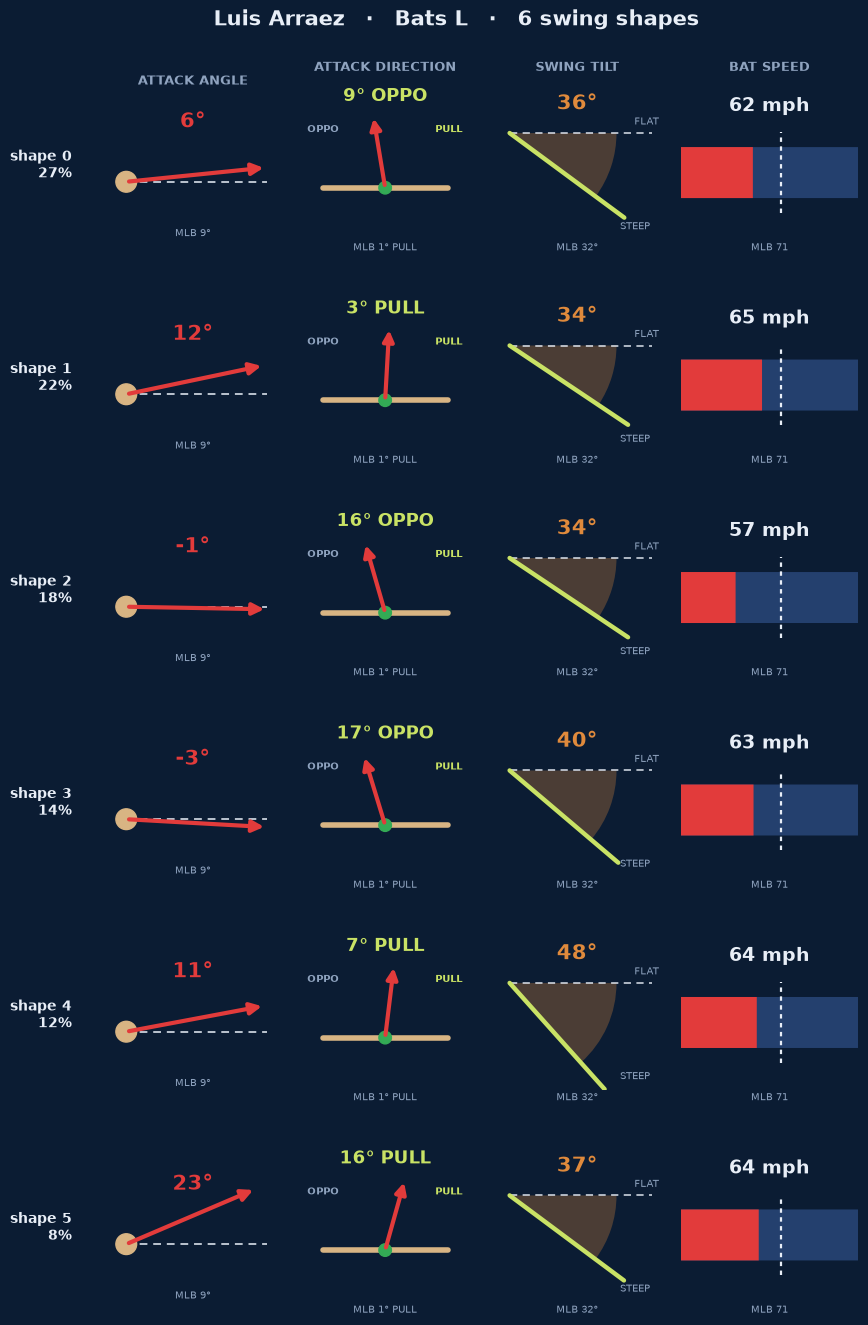

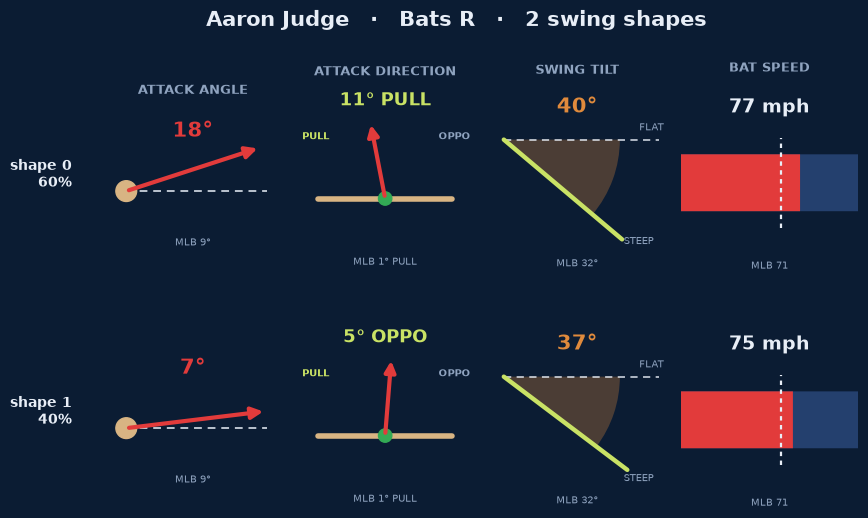

In [73]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Wedge, Circle, FancyBboxPatch

# Savant-style palette
BG, INK, MUT = '#0b1c33', '#e8eef7', '#8fa3bf'
RED, TAN, LIME, ORNG, GRID = '#e23b3b', '#d8b483', '#c9e265', '#e08a3c', '#24406e'

# MLB-average references, from the clustered cohort
LEAGUE = {c: swc[c].mean() for c in
          ['bat_speed', 'vert_attack_angle', 'horz_attack_angle_pull', 'swing_path_tilt']}


def _off(ax):
    ax.set_facecolor(BG); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


def _p_aa(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-1.15, 1.25); ax.set_ylim(-0.6, 1.05)
    a = np.radians(r.vaa)
    ax.add_patch(Circle((-0.85, 0), 0.14, color=TAN, zorder=3))
    ax.plot([-0.85, 1.05], [0, 0], color=INK, ls=(0, (4, 3)), lw=1.4, alpha=.8)
    ax.add_patch(FancyArrowPatch((-0.85, 0), (-0.85 + 1.9*np.cos(a), 1.9*np.sin(a)),
                 arrowstyle='-|>', mutation_scale=17, color=RED, lw=3, zorder=4))
    ax.text(0.5, 0.94, f"{r.vaa:.0f}°", transform=ax.transAxes, ha='center', va='top',
            color=RED, fontsize=15, fontweight='bold')


def _p_dir(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.0, 1.15)
    # haa is in the pull frame (+ = pull for both hands). A LHH's pull is right field, so flip the
    # screen orientation for lefties: the arrow leans toward the hitter's real pull side and the
    # PULL/OPPO labels move with it. Magnitude + pull/oppo text are unchanged (frame-invariant).
    s = -1.0 if getattr(r, 'stand', 'R') == 'L' else 1.0
    ang = np.radians(r.haa) * s
    ax.plot([-0.9, 0.9], [-0.25, -0.25], color=TAN, lw=4, solid_capstyle='round')
    ax.add_patch(Circle((0, -0.25), 0.09, color='#3a5', zorder=3))
    ax.add_patch(FancyArrowPatch((0, -0.25), (-np.sin(ang)*1.05, -0.25 + np.cos(ang)*1.05),
                 arrowstyle='-|>', mutation_scale=16, color=RED, lw=3, zorder=4))
    pull_x, oppo_x = ((-1.12, 0.72) if s > 0 else (0.72, -1.12))
    ax.text(pull_x, 0.55, 'PULL', color=LIME, fontsize=7.5, fontweight='bold')
    ax.text(oppo_x, 0.55, 'OPPO', color=MUT, fontsize=7.5, fontweight='bold')
    ax.text(0.5, 1.02, f"{abs(r.haa):.0f}° {'PULL' if r.haa >= 0 else 'OPPO'}",
            transform=ax.transAxes, ha='center', va='top', color=LIME, fontsize=13, fontweight='bold')


def _p_tilt(ax, r):
    _off(ax); ax.set_aspect('equal'); ax.set_xlim(-0.2, 2.1); ax.set_ylim(-1.5, 0.6)
    t = r.tilt
    ax.add_patch(Wedge((0, 0), 1.5, -t, 0, facecolor=ORNG, alpha=.30))
    ax.plot([0, 2.0], [0, 0], color=INK, ls=(0, (4, 3)), lw=1.3, alpha=.8)
    ax.plot([0, 2.0*np.cos(np.radians(t))], [0, -2.0*np.sin(np.radians(t))], color=LIME, lw=3.2,
            solid_capstyle='round')
    ax.text(1.75, 0.12, 'FLAT', color=MUT, fontsize=7); ax.text(1.55, -1.35, 'STEEP', color=MUT, fontsize=7)
    ax.text(0.5, 0.98, f"{r.tilt:.0f}°", transform=ax.transAxes, ha='center', va='top',
            color=ORNG, fontsize=15, fontweight='bold')


def _p_speed(ax, r):
    _off(ax); ax.set_xlim(40, 95); ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch((40, 0.28), 55, 0.34, boxstyle='round,pad=0.02',
                 mutation_aspect=0.02, facecolor=GRID, edgecolor='none'))
    ax.add_patch(FancyBboxPatch((40, 0.28), r.speed-40, 0.34, boxstyle='round,pad=0.02',
                 mutation_aspect=0.02, facecolor=RED, edgecolor='none'))
    ax.plot([LEAGUE['bat_speed']]*2, [0.18, 0.72], color=INK, lw=1.6, ls=(0, (2, 2)))
    ax.text(0.5, 0.96, f"{r.speed:.0f} mph", transform=ax.transAxes, ha='center', va='top',
            color=INK, fontsize=14, fontweight='bold')


COLS = [('ATTACK ANGLE', _p_aa, f"MLB {LEAGUE['vert_attack_angle']:.0f}°"),
        ('ATTACK DIRECTION', _p_dir,
         f"MLB {abs(LEAGUE['horz_attack_angle_pull']):.0f}° {'PULL' if LEAGUE['horz_attack_angle_pull'] >= 0 else 'OPPO'}"),
        ('SWING TILT', _p_tilt, f"MLB {LEAGUE['swing_path_tilt']:.0f}°"),
        ('BAT SPEED', _p_speed, f"MLB {LEAGUE['bat_speed']:.0f}")]

# Header/footer are reserved in ABSOLUTE INCHES, not as a fraction of the figure. The figure height
# grows with the number of shapes (ROW_IN per cluster), so a fixed top-fraction would shrink to a
# few tenths of an inch for low-k hitters (e.g. Judge, k=2) and let the suptitle collide with the
# column titles and the row-0 metric text. Fixed inches keep the same visual gap at any k.
HEADER_IN, FOOTER_IN, ROW_IN = 1.15, 0.45, 2.02


def swing_cards(name, save=None):
    """Static Savant-style card matrix (one row per cluster) for one hitter."""
    d = swc[swc.batter_full_name.str.contains(name, case=False, na=False)]
    who = d.batter_full_name.unique()
    if len(who) != 1:
        raise ValueError(f'{name!r} matches {list(who)} - be more specific')
    full, stand = who[0], d.batter_stand.mode().iloc[0]
    g = (d.groupby('cluster').agg(n=('play_id', 'size'), tilt=('swing_path_tilt', 'mean'),
         speed=('bat_speed', 'mean'), vaa=('vert_attack_angle', 'mean'),
         haa=('horz_attack_angle_pull', 'mean')).reset_index())
    g['weight'] = g.n / g.n.sum(); g['stand'] = stand; g = g.sort_values('weight', ascending=False)
    k, nc = len(g), len(COLS)
    fig_h = HEADER_IN + FOOTER_IN + ROW_IN * k
    fig, axes = plt.subplots(k, nc, figsize=(2.05*nc, fig_h),
                             gridspec_kw=dict(wspace=0.08, hspace=0.42))
    axes = np.atleast_2d(axes); fig.patch.set_facecolor(BG)
    for j, (title, _, _) in enumerate(COLS):
        axes[0, j].set_title(title, color=MUT, fontsize=9.5, fontweight='bold', pad=14)
    for i, (_, r) in enumerate(g.iterrows()):
        axes[i, 0].text(-0.18, 0.5, f"shape {int(r.cluster)}\n{r.weight*100:.0f}%",
                        transform=axes[i, 0].transAxes, ha='right', va='center',
                        color=INK, fontsize=10, fontweight='bold')
        for j, (_, fn, avg) in enumerate(COLS):
            fn(axes[i, j], r)
            if avg:
                axes[i, j].text(0.5, -0.02, avg, transform=axes[i, j].transAxes,
                                ha='center', va='top', color=MUT, fontsize=7)
    # suptitle sits a fixed 0.34" below the top edge; the axes grid starts HEADER_IN below it, so
    # the title clears the column titles at any k.
    fig.suptitle(f"{full}   ·   Bats {stand}   ·   {k} swing shapes", color=INK,
                 fontsize=15, fontweight='bold', y=1 - 0.34 / fig_h)
    fig.subplots_adjust(left=0.07, right=0.99,
                        top=1 - HEADER_IN / fig_h, bottom=FOOTER_IN / fig_h)
    if save:
        fig.savefig(save, dpi=130, facecolor=BG, bbox_inches='tight'); print('wrote', save)
    return fig


swing_cards('Arraez', save=PLOTS / 'swing_cards_arraez.png');
swing_cards('Judge', save=PLOTS / 'swing_cards_judge.png');

## Cluster usage by game state (heatmap)

`usage_heatmap(name)` — pass any hitter's name (substring match). Each cell is **P(cluster | game state)**: within a situation, the share of that hitter's swings falling in each shape (columns sum to 100%).

In [72]:
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
import dataframe_image as dfi

# fivethirtyeight-consistent diverging palette (blue -> white -> red), matches the notebook plots
FT_DIV = LinearSegmentedColormap.from_list('ft_div', ['#30a2da', '#FFFFFF', '#fc4f30'])
# fastballs = four-seam, sinker, cutter, generic fastball (FT/two-seamer folded into SI by Statcast);
# everything else (SL/ST/CU/KC/SV/CH/FS/FO/KN/...) = secondary
FASTBALLS = {'FF', 'SI', 'FC', 'FT', 'FA'}

def usage_heatmap(name):
    """Cluster-usage heatmap by game state for one hitter (substring match on batter_full_name).
    Each cell = P(cluster | state) as a %, columns sum to 100. Color runs column-wise: within a
    game state, red = the shape used most there, blue = least. Returns the styled table."""
    d = swc[swc.batter_full_name.str.contains(name, case=False, na=False)]
    names = d.batter_full_name.unique()
    if len(names) == 0:
        raise ValueError(f'no batter matches {name!r}')
    if len(names) > 1:
        raise ValueError(f'{name!r} matches {len(names)} batters: {list(names)} — be more specific')
    full = names[0]
    k = int(d.cluster.max()) + 1
    b, s, o, pt = d.balls, d.strikes, d.outs_when_up, d.pitch_type
    on1, on2, on3 = d.on_1b_id.notna(), d.on_2b_id.notna(), d.on_3b_id.notna()
    is_fb = pt.isin(FASTBALLS)

    masks = {
        'All':     None,
        '0-0':     (b == 0) & (s == 0),
        '2 strk':  s == 2,
        '0-2':     (b == 0) & (s == 2),
        'Full':    (b == 3) & (s == 2),
        'vs FB':   is_fb,
        'vs Sec':  pt.notna() & ~is_fb,
        'Empty':   ~(on1 | on2 | on3),
        'RISP':    on2 | on3,
        '0 out':   o == 0,
        '1 out':   o == 1,
        '2 out':   o == 2,
    }
    dist = lambda m: ((d if m is None else d[m]).cluster
                      .value_counts(normalize=True).reindex(range(k), fill_value=0) * 100)
    usage = pd.DataFrame({nm: dist(m) for nm, m in masks.items()})
    usage.index.name = 'cluster'
    support = pd.Series({nm: (len(d) if m is None else int(m.sum())) for nm, m in masks.items()},
                        name='n swings').to_frame().T

    return (usage.style
            .background_gradient(cmap=FT_DIV, axis=0, low=0.1, high=0.1)   # column-wise: red = most-used shape in that state
            .format('{:.0f}%')
            .set_caption(f'{full} - cluster usage % by game state')
            .set_table_styles([
                {'selector': '', 'props': [('background-color', 'white'), ('color', '#3c3c3c'),
                                           ('font-family', 'sans-serif'), ('border-collapse', 'collapse')]},
                {'selector': 'th', 'props': [('background-color', 'white'), ('color', '#3c3c3c'),
                                             ('border', '1px solid #cbcbcb'), ('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('border', '1px solid #ececec')]},
                {'selector': 'caption', 'props': [('caption-side', 'top'), ('color', '#3c3c3c'),
                                                  ('font-size', '13px'), ('font-weight', 'bold'),
                                                  ('padding-bottom', '6px')]},
            ]))
    
_hm = usage_heatmap('Arraez')
dfi.export(_hm, str(PLOTS / 'usage_heatmap_arraez.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'usage_heatmap_arraez.png')
_hm

_hm = usage_heatmap('Judge')
dfi.export(_hm, str(PLOTS / 'usage_heatmap_judge.png'), table_conversion='matplotlib')
print('wrote', PLOTS / 'usage_heatmap_judge.png')
_hm

wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\usage_heatmap_arraez.png
wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\usage_heatmap_judge.png


,All,0-0,2 strk,0-2,Full,vs FB,vs Sec,Empty,RISP,0 out,1 out,2 out
cluster,,,,,,,,,,,,
0,60%,60%,60%,57%,60%,44%,78%,60%,59%,60%,59%,61%
1,40%,40%,40%,43%,40%,56%,22%,40%,41%,40%,41%,39%


## Archetype lexicon (Layer 1) — eyeballing the vocabulary

The per-batter clusters are bare indices. Layer 1 (`src/interpret.py`) maps every unit-cluster onto **3 league archetypes**: **Level Oppo / Level Center / Uppercut Pull**. After the handedness fix (pull frame corrected — see below), MLB swing geometry sits on a **level-oppo ↔ uppercut-pull diagonal** (uppercut swings are pull-side), so BIC lands on 3, not a 2×2. `bat_speed` is a **descriptor, not a defining axis**.

Three checks below:
1. **Bat speed vs uppercut** — the correlation motivating the descriptor choice: effort rises with lift, so `bat_speed` is partly redundant with `vert_attack_angle`.
2. **`archetype_map(name)`** — any hitter's shapes on the league grid (x = pull frame, **+ = pull for both hands**); bubble = usage, label = cluster · bat speed.
3. **Collision curve** — a 3-word vocabulary can't uniquely name every shape of a multi-shape hitter, so labels saturate; multi-shape hitters lean on Layer 2 (delta-vs-primary + the situational tag) to separate same-label shapes.

In [57]:
# --- Layer-1 archetype lexicon (src/interpret.py output) ---
arch    = pd.read_parquet(DATA / 'shape_archetypes.parquet')   # one row per (unit, cluster): archetype tag
lexicon = pd.read_parquet(DATA / 'archetype_lexicon.parquet')  # the league archetype vocabulary

# palette ordered by lift: level = cool, uppercut = warm. After the handedness fix the geometry is a
# level-oppo <-> uppercut-pull diagonal, so 3 archetypes: Level Oppo / Level Center / Uppercut Pull.
ARCH_PAL = {'Level Oppo': '#7EA6D6', 'Level Center': '#d8b483', 'Uppercut Pull': '#e23b3b'}
ARCH_ORDER = [a for a in ['Level Oppo', 'Level Center', 'Uppercut Pull']
              if a in set(arch.archetype_name)]
display(lexicon)

,archetype,archetype_name,n_shapes,tilt,len,vaa,haa_pull,bat_speed
0,0,Level Oppo,1006,31.41,6.83,4.90,-7.14,69.65
1,1,Uppercut Pull,586,33.40,8.00,17.81,15.76,71.36


wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\archetype_batspeed_vs_vaa.png


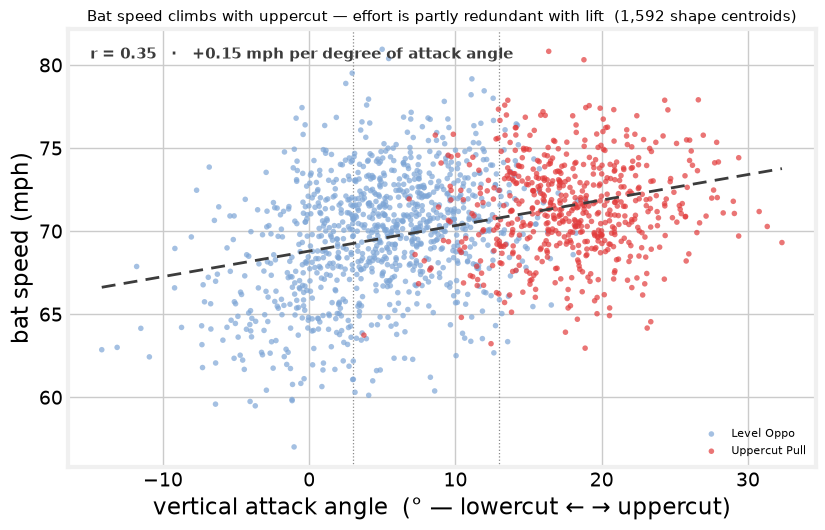

In [58]:
import matplotlib.pyplot as plt

# The requested correlation: does bat speed rise with uppercut (vertical attack angle)?
# fivethirtyeight theme, white background (per user).
with plt.style.context('fivethirtyeight'):
    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                         'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'})
    DARK = '#3c3c3c'
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    for a in ARCH_ORDER:
        s = arch[arch.archetype_name == a]
        ax.scatter(s.vert_attack_angle, s.bat_speed, s=16, c=ARCH_PAL[a], alpha=0.7,
                   edgecolor='none', label=a, zorder=3)
    x, y = arch.vert_attack_angle, arch.bat_speed
    b1, b0 = np.polyfit(x, y, 1); r = np.corrcoef(x, y)[0, 1]
    xs = np.array([x.min(), x.max()])
    ax.plot(xs, b0 + b1 * xs, color=DARK, lw=2, ls=(0, (5, 3)), zorder=4)
    for v in (3, 13):                                       # flat | level | uppercut boundaries
        ax.axvline(v, color='#8a8a8a', lw=0.9, ls=':')
    ax.text(0.03, 0.96, f"r = {r:.2f}   ·   +{b1:.2f} mph per degree of attack angle",
            transform=ax.transAxes, color=DARK, fontsize=11, fontweight='bold', va='top')
    ax.set_xlabel('vertical attack angle  (° — lowercut ← → uppercut)')
    ax.set_ylabel('bat speed (mph)')
    ax.set_title(f'Bat speed climbs with uppercut — effort is partly redundant with lift  ({len(arch):,} shape centroids)', fontsize=11)
    ax.legend(loc='lower right', frameon=False, fontsize=8)
    fig.savefig(PLOTS / 'archetype_batspeed_vs_vaa.png', dpi=130, bbox_inches='tight')
    print('wrote', PLOTS / 'archetype_batspeed_vs_vaa.png')
    plt.show()

## Repertoire size — distribution across the cohort

How many distinct swing shapes each `(batter, stand)` unit carries: post-merge **k** (a hard count) and **effective_shapes** (usage-weighted `exp(entropy)`, discounting rarely-used shapes).

wrote c:\Users\theo.an-yeung\Desktop\Driveline\swing-repertoire\results\plots\repertoire_size_distribution.png


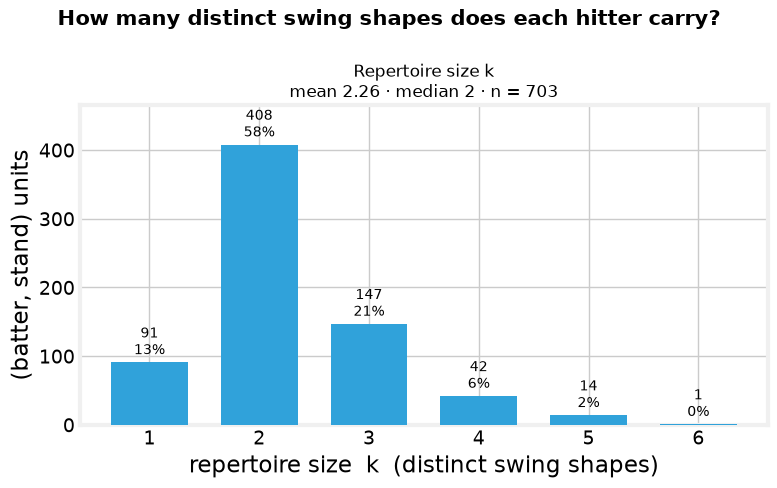

In [63]:
import matplotlib.pyplot as plt

# Distribution of how many distinct swing shapes each (batter, stand) unit carries.
# Left: repertoire size k (post-merge shape count). Right: effective_shapes = exp(usage entropy) --
# the usage-weighted 'effective number of shapes actually used' (discounts rarely-used shapes).
with plt.style.context('fivethirtyeight'):
    plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                         'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'})
    
    fig, ax = plt.subplots(figsize=(8, 5))
    kc = rep.k.value_counts().sort_index()
    ax.bar(kc.index, kc.values, color='#30a2da', width=0.7, zorder=3)
    for x, v in zip(kc.index, kc.values):
        ax.text(x, v + 5, f'{v}\n{v / len(rep) * 100:.0f}%', ha='center', va='bottom', fontsize=10)
    ax.set_xticks(kc.index)
    ax.set_xlabel('repertoire size  k  (distinct swing shapes)')
    ax.set_ylabel('(batter, stand) units')
    ax.set_title(f'Repertoire size k\nmean {rep.k.mean():.2f} · median {int(rep.k.median())} · n = {len(rep)}', fontsize=12)
    ax.margins(y=0.14)

    fig.suptitle('How many distinct swing shapes does each hitter carry?', fontsize=15, fontweight='bold')
    fig.tight_layout()
    fig.savefig(PLOTS / 'repertoire_size_distribution.png', dpi=130, bbox_inches='tight')
    print('wrote', PLOTS / 'repertoire_size_distribution.png')
    plt.show()